## gauss

/tmp/ipykernel_470485/2821770523.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trap   = np.trapz(f(x_trap), x_trap)


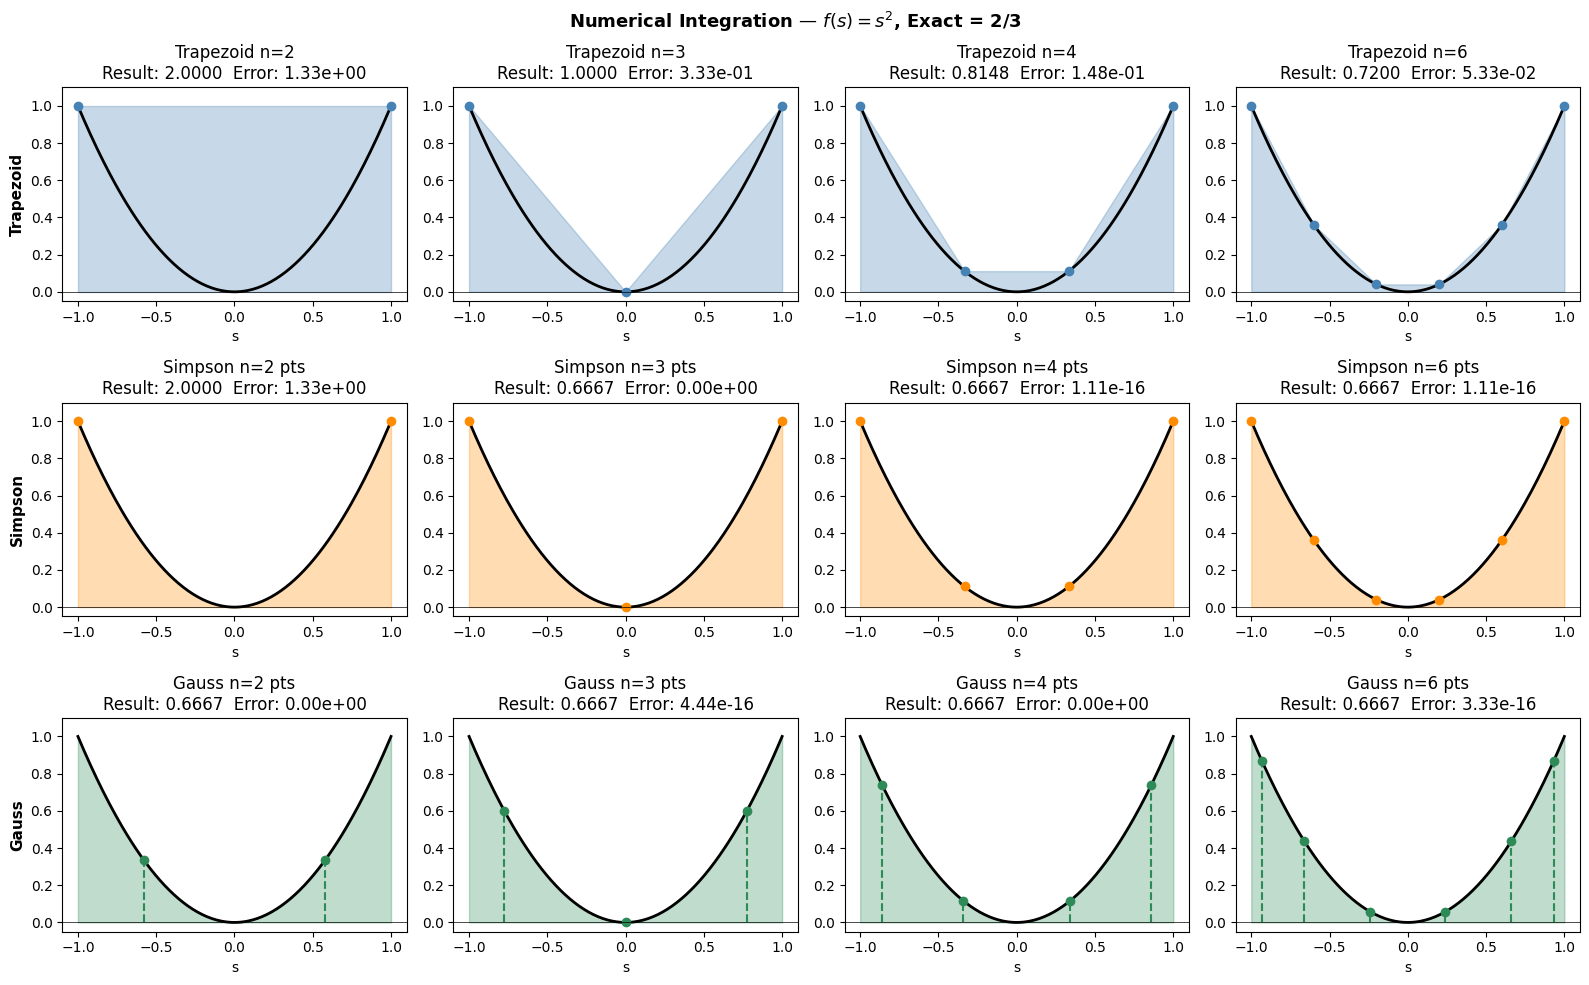

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre
from scipy.integrate import simpson as simp_rule

f      = lambda s: s**2
exacta = 2/3                        # exact integral of s^2 in [-1, 1]
s_plot = np.linspace(-1, 1, 200)
n_list = [2, 3, 4, 6]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for col, n in enumerate(n_list):

    # --- Trapezoid ---
    x_trap = np.linspace(-1, 1, n)
    trap   = np.trapz(f(x_trap), x_trap)
    ax = axes[0, col]
    ax.plot(s_plot, f(s_plot), 'k', lw=2)
    ax.fill_between(x_trap, f(x_trap), alpha=0.3, color='steelblue')
    ax.plot(x_trap, f(x_trap), 'o', color='steelblue', ms=6)
    ax.set_title(f'Trapezoid n={n}\nResult: {trap:.4f}  Error: {abs(trap-exacta):.2e}')
    ax.set_xlabel('s')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-0.05, 1.1)

    # --- Simpson ---
    n_simp = max(n, 2)
    x_simp = np.linspace(-1, 1, n_simp)
    simp   = simp_rule(f(x_simp), x=x_simp)
    ax = axes[1, col]
    ax.plot(s_plot, f(s_plot), 'k', lw=2)
    ax.fill_between(s_plot, f(s_plot), alpha=0.3, color='darkorange')
    ax.plot(x_simp, f(x_simp), 'o', color='darkorange', ms=6)
    ax.set_title(f'Simpson n={n_simp} pts\nResult: {simp:.4f}  Error: {abs(simp-exacta):.2e}')
    ax.set_xlabel('s')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-0.05, 1.1)

    # --- Gauss (no transformation needed, domain is already [-1, 1]) ---
    roots, weights = roots_legendre(n)
    gauss = np.sum(weights * f(roots))
    ax = axes[2, col]
    ax.plot(s_plot, f(s_plot), 'k', lw=2)
    ax.fill_between(s_plot, f(s_plot), alpha=0.3, color='seagreen')
    ax.vlines(roots, 0, f(roots), color='seagreen', lw=1.5, linestyle='--')
    ax.plot(roots, f(roots), 'o', color='seagreen', ms=6)
    ax.set_title(f'Gauss n={n} pts\nResult: {gauss:.4f}  Error: {abs(gauss-exacta):.2e}')
    ax.set_xlabel('s')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-0.05, 1.1)

axes[0, 0].set_ylabel('Trapezoid', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Simpson', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Gauss', fontsize=11, fontweight='bold')

fig.suptitle('Numerical Integration — $f(s) = s^2$, Exact = 2/3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## $x^2$

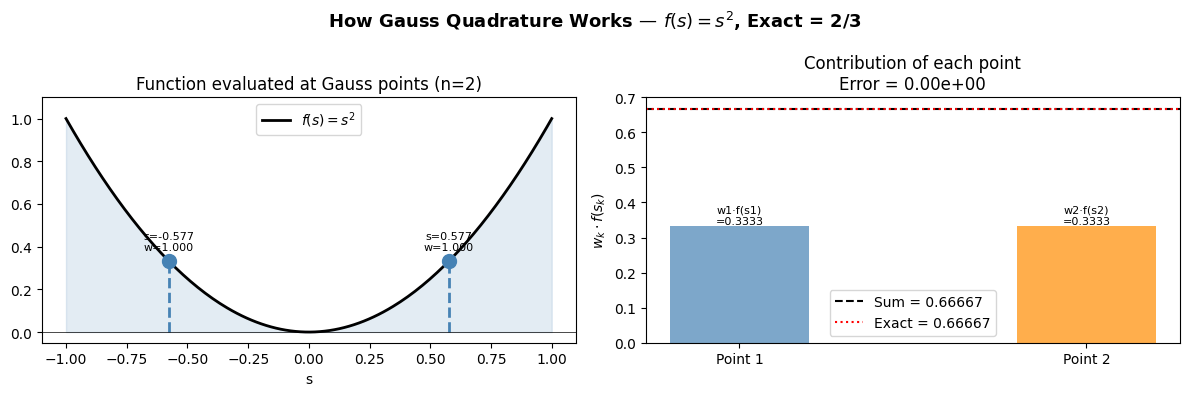

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre

f      = lambda s: s**2
exacta = 2/3
s_plot = np.linspace(-1, 1, 200)
n      = 2

roots, weights = roots_legendre(n)

# No transformation needed — domain is already [-1, 1]
result = np.sum(weights * f(roots))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: function evaluated at Gauss points ---
ax = axes[0]
ax.plot(s_plot, f(s_plot), 'k', lw=2, label='$f(s) = s^2$')
ax.fill_between(s_plot, f(s_plot), alpha=0.15, color='steelblue')
for sk, wk in zip(roots, weights):
    ax.plot([sk, sk], [0, f(sk)], color='steelblue', lw=2, linestyle='--')
    ax.plot(sk, f(sk), 'o', color='steelblue', ms=10)
    ax.text(sk, f(sk)+0.05, f's={sk:.3f}\nw={wk:.3f}', ha='center', fontsize=8)
ax.axhline(0, color='k', lw=0.5)
ax.set_title(f'Function evaluated at Gauss points (n={n})')
ax.set_xlabel('s')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.legend()

# --- Right: contribution of each Gauss point ---
ax = axes[1]
contribs = weights * f(roots)
colors   = ['steelblue', 'darkorange', 'seagreen', 'red']
bars = ax.bar(range(n), contribs, color=colors[:n], alpha=0.7, width=0.4)
ax.axhline(result, color='k', lw=1.5, linestyle='--', label=f'Sum = {result:.5f}')
ax.axhline(exacta, color='red', lw=1.5, linestyle=':', label=f'Exact = {exacta:.5f}')
for i, (b, c) in enumerate(zip(bars, contribs)):
    ax.text(i, c + 0.005, f'w{i+1}·f(s{i+1})\n={c:.4f}', ha='center', fontsize=8)
ax.set_xticks(range(n))
ax.set_xticklabels([f'Point {k+1}' for k in range(n)])
ax.set_title(f'Contribution of each point\nError = {abs(result-exacta):.2e}')
ax.set_ylabel('$w_k \cdot f(s_k)$')
ax.legend()

fig.suptitle('How Gauss Quadrature Works — $f(s) = s^2$, Exact = 2/3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## cos (x)

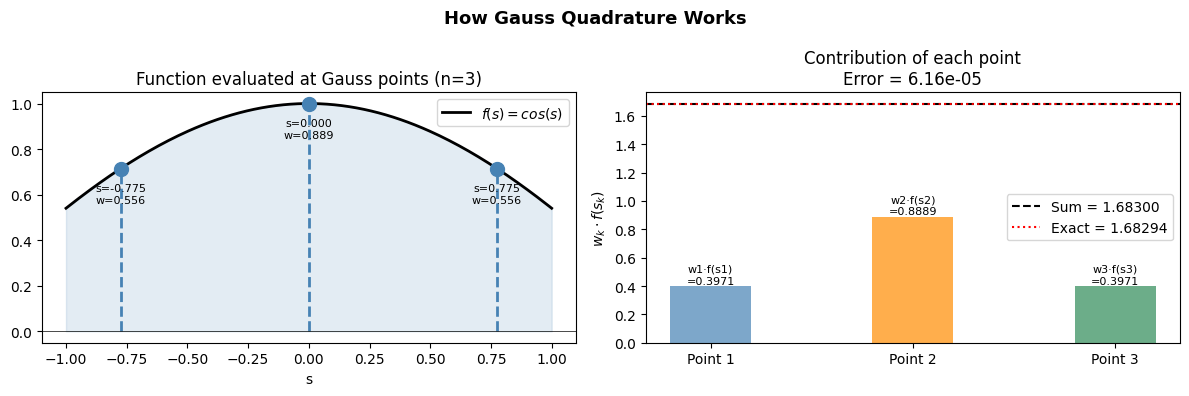

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre

f      = lambda s: np.cos(s)   # any function
exacta = 2 * np.sin(1)         # exact integral of cos in [-1, 1]
s_plot = np.linspace(-1, 1, 200)
n      = 3

roots, weights = roots_legendre(n)

# Gauss sum
result = np.sum(weights * f(roots))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: function evaluated at Gauss points ---
ax = axes[0]
ax.plot(s_plot, f(s_plot), 'k', lw=2, label='$f(s) = cos(s)$')
ax.fill_between(s_plot, f(s_plot), alpha=0.15, color='steelblue')
for sk, wk in zip(roots, weights):
    ax.plot([sk, sk], [0, f(sk)], color='steelblue', lw=2, linestyle='--')
    ax.plot(sk, f(sk), 'o', color='steelblue', ms=10)
    ax.text(sk, f(sk)-0.15, f's={sk:.3f}\nw={wk:.3f}', ha='center', fontsize=8)
ax.axhline(0, color='k', lw=0.5)
ax.set_title(f'Function evaluated at Gauss points (n={n})')
ax.set_xlabel('s')
ax.legend()

# --- Right: contribution of each Gauss point ---
ax = axes[1]
contribs = weights * f(roots)
colors   = ['steelblue', 'darkorange', 'seagreen', 'red']
bars = ax.bar(range(n), contribs, color=colors[:n], alpha=0.7, width=0.4)
ax.axhline(result, color='k', lw=1.5, linestyle='--', label=f'Sum = {result:.5f}')
ax.axhline(exacta, color='red', lw=1.5, linestyle=':', label=f'Exact = {exacta:.5f}')
for i, (b, c) in enumerate(zip(bars, contribs)):
    ax.text(i, c + 0.02, f'w{i+1}·f(s{i+1})\n={c:.4f}', ha='center', fontsize=8)
ax.set_xticks(range(n))
ax.set_xticklabels([f'Point {k+1}' for k in range(n)])
ax.set_title(f'Contribution of each point\nError = {abs(result-exacta):.2e}')
ax.set_ylabel('$w_k \cdot f(s_k)$')
ax.legend()

fig.suptitle('How Gauss Quadrature Works', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## w gauss

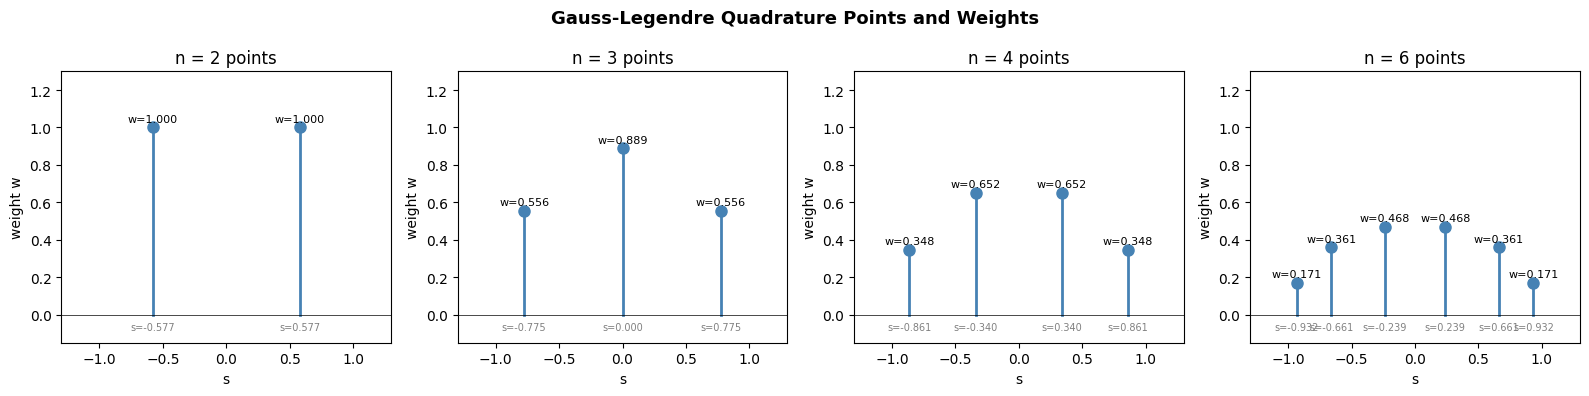

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre

x_plot = np.linspace(-1, 1, 200)
n_list = [2, 3, 4 , 6]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n in zip(axes, n_list):
    roots, weights = roots_legendre(n)

    # Plot weight as vertical bar (pyramid shape)
    for xi, wi in zip(roots, weights):
        ax.plot([xi, xi], [0, wi], color='steelblue', lw=2)
        ax.plot(xi, wi, 'o', color='steelblue', ms=8)
        ax.text(xi, wi + 0.03, f'w={wi:.3f}', ha='center', fontsize=8)
        ax.text(xi, -0.08, f's={xi:.3f}', ha='center', fontsize=7, color='gray')

    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.15, 1.3)
    ax.set_title(f'n = {n} points')
    ax.set_xlabel('s')
    ax.set_ylabel('weight w')

fig.suptitle('Gauss-Legendre Quadrature Points and Weights', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()